## Vamos usar esta base:

https://www.kaggle.com/datasets/vishakhdapat/waiter-tip-prediction

**Realizando a importacao da base de dados via Kaggle API Token**

In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets list
!kaggle datasets download -d vishakhdapat/waiter-tip-prediction

# Upload the file "kaggle.json" for authentication when is requested

Saving kaggle.json to kaggle (2).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists
ref                                                                 title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset              Screen Time, Sleep & Stress Analysis Dataset           787136  2026-02-13 06:56:18.757000          10763        213  1.0              
amar5693/student-performance-dataset                                Student Performance Dataset                            177286  2026-02-12 06:04:44.613000           9105        148  1.0              
aliiihussain/amazon-sales-dataset                                   Amazon_Sales_Dataset  

**Descompactando e alterando o caminho do arquivo**

In [ ]:
import shutil
import os

! unzip waiter-tip-prediction

src_file = 'tips.csv'
dest_file = '/home/tips.csv'

shutil.move(src_file, dest_file)
print(f"Moved '{src_file}' to '{dest_file}' with sucess!")

Archive:  waiter-tip-prediction.zip
  inflating: tips.csv                
Moved 'tips.csv' to '/home/tips.csv' with sucess!


# **Importando as bibliotecas e lendo a base de dados**

In [ ]:
import pandas as pd # Data processing, reading CSV file
import numpy as np # Mean and std. deviation for Learning curve
import matplotlib.pyplot as plt

# Data treatment
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning (Random Forest/Decision Tree)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Plot Decision Tree (Not used)
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz, plot_tree
import pydotplus

# Validation
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import learning_curve

In [ ]:
df = pd.read_csv('/home/tips.csv')
print(df.shape)
df.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# **EDA**

In [ ]:
print("Data types of the columns:\n\n"
      "Column    Type")
df.dtypes

Data types of the columns:

Column    Type


,0
total_bill,float64
tip,float64
sex,object
smoker,object
day,object
time,object
size,int64


Verificando se ha valores nulos

In [ ]:
nulls = df.isnull().sum()
total_nulls = nulls.sum()
if total_nulls == 0:
    print("There are no null values ​​in the DataFrame.")
else:
    print("Null values founded:\n")
    print(nulls[nulls > 0])
    labels = ['Nulls', 'Not Nulls']
    values = [total_nulls, df.size - total_nulls]
    plt.figure(figsize=(6, 6))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
    plt.title('Proportion of Null Values in the DataFrame')
    plt.axis('Equal')
    plt.show()

There are no null values ​​in the DataFrame.


# **Feature Engineering**

**1.1** Transformar todas as variaveis categoricas em variaveis dummy

In [ ]:
df1 = df.copy()

In [ ]:
columns_to_count = ['sex', 'smoker', 'day', 'time']

for col in columns_to_count:
    print(f"Value counts for '{col}':")
    print(df1[col].value_counts())
    print("\n")

Value counts for 'sex':
sex
Male      157
Female     87
Name: count, dtype: int64


Value counts for 'smoker':
smoker
No     151
Yes     93
Name: count, dtype: int64


Value counts for 'day':
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


Value counts for 'time':
time
Dinner    176
Lunch      68
Name: count, dtype: int64




In [ ]:
df1['sex'] = df1['sex'].apply(lambda x: 1 if x == 'Male' else 0)
df1['smoker'] = df1['smoker'].apply(lambda x: 1 if x == 'No' else 0)

df1['Sat'] = df1['day'].apply(lambda x: 1 if x == 'Sat' else 0)
df1['Sun'] = df1['day'].apply(lambda x: 1 if x == 'Sun' else 0)
df1['Thur'] = df1['day'].apply(lambda x: 1 if x == 'Thur' else 0)
df1['Fri'] = df1['day'].apply(lambda x: 1 if x == 'Fri' else 0)

df1['time'] = df1['time'].apply(lambda x: 1 if x == 'Dinner' else 0)

df1 = df1.drop('day', axis=1)
df1.head()

,total_bill,tip,sex,smoker,time,size,Sat,Sun,Thur,Fri
0,16.99,1.01,0,1,1,2,0,1,0,0
1,10.34,1.66,1,1,1,3,0,1,0,0
2,21.01,3.50,1,1,1,3,0,1,0,0
3,23.68,3.31,1,1,1,2,0,1,0,0
4,24.59,3.61,0,1,1,4,0,1,0,0


**2.1** Criar uma nova variavel indicando o percentual da gorjeta em relacao ao valor total da refeicao

**3.1** Encontrar um valor limite para a nova variavel que balanceie a amostra em 50%/50%.

**4.1** Criar uma nova variavel de classificacao utilizando esse valor limite

In [ ]:
df1['tip_total_bill'] = df1.apply(lambda x: x['tip'] / x['total_bill'], axis=1)
median = df1['tip_total_bill'].median()
df1['tip_total_bill'] = df1['tip_total_bill'].apply(lambda x: 1 if x > median else 0)
df1 = df1.drop('total_bill', axis=1)
df1 = df1.drop('tip', axis=1)
df1.head()

,sex,smoker,time,size,Sat,Sun,Thur,Fri,tip_total_bill
0,0,1,1,2,0,1,0,0,0
1,1,1,1,3,0,1,0,0,1
2,1,1,1,3,0,1,0,0,1
3,1,1,1,2,0,1,0,0,0
4,0,1,1,4,0,1,0,0,0


In [ ]:
df1['tip_total_bill'].value_counts()

,count
tip_total_bill,
0,122
1,122


# **Decision Tree**

**1.2** Criar um algoritmo de Decision Tree que tente prever se a gorjeta foi alta ou baixa, a partir do valor limite descoberto

In [ ]:
x = df1.drop("tip_total_bill", axis=1)
y = df1["tip_total_bill"]
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.3, random_state=42)

In [ ]:
# Decision Tree
classifier = DecisionTreeClassifier(criterion='log_loss', min_samples_leaf=3, max_depth=10, random_state=42)
classifier.fit(x_train, y_train)
y_pred_train = classifier.predict(x_train)
y_pred_test = classifier.predict(x_test)

print("Accuracy (Train):", metrics.accuracy_score(y_train, y_pred_train))
print("Accuracy (Test):", metrics.accuracy_score(y_test, y_pred_test))

Accuracy (Train): 0.6647058823529411
Accuracy (Test): 0.44594594594594594


In [ ]:
# Plot da Decision Tree abaixo:

# dot_data = StringIO()
# export_graphviz(classifier, out_file=dot_data,
#                 filled=True, rounded=True,
#                 special_characters=True, feature_names = ['sex', 'smoker', 'time', 'size', 'Sat', 'Sun',
#                                                           'Thur', 'Fri'], class_names=['0','1'])
# graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
# graph.write_png('image.png')
# Image(graph.create_png())

**2.2** Verifique qual o melhor criterio para ser utilizado na Decision Tree a partir da metrica Accuracy

In [ ]:
d = {'entropy':0, 'gini':0, 'log_loss':0}
for k in d.keys():
  classifier = DecisionTreeClassifier(criterion=k, min_samples_leaf=3, max_depth=10, random_state=42)
  classifier.fit(x_train, y_train)
  y_pred = classifier.predict(x_test)

  print(f"Accuracy ({k}):",metrics.accuracy_score(y_test, y_pred))
  d[k] = metrics.accuracy_score(y_test, y_pred)

print('-'*50)
print(f"Best metric/accuracy -", max(d, key=d.get)+":", max(d.values()))

Accuracy (entropy): 0.44594594594594594
Accuracy (gini): 0.44594594594594594
Accuracy (log_loss): 0.44594594594594594
--------------------------------------------------
Best metric/accuracy - entropy: 0.44594594594594594


**3.2** Teste valores de 1 a 10 para o hiperparâmetro **max_depth**. Analise a curva de métrica accuracy com o deslocamento do **max_depth**. Para a sua análise, inclua o hiperparâmetro **random_state**.

In [ ]:
accuracies_tree = []


for k in range(1,11):
  clf_dt = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=3, max_depth=k, random_state=42)
  clf_dt.fit(x_train, y_train)
  y_pred = clf_dt.predict(x_test)

  accuracy = metrics.accuracy_score(y_test, y_pred)
  print(f"Accuracy (Max Depth {k}):", accuracy)
  accuracies_tree.append({'max_depth': k, 'Accuracy': accuracy})
  clf_report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True))


print("\n"+'-'*100)
results_df_tree = pd.DataFrame(accuracies_tree)
best_acc_tree = results_df_tree.loc[results_df_tree["Accuracy"].idxmax()]

print(f"Accuracy Max (Max Depth {int(best_acc_tree['max_depth'])}): {best_acc_tree['Accuracy']}")
print('-'*100)
print(f"Classification Report:\n{clf_report}")
print('-'*100)
print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}\n")

Accuracy (Max Depth 1): 0.4864864864864865
Accuracy (Max Depth 2): 0.5540540540540541
Accuracy (Max Depth 3): 0.43243243243243246
Accuracy (Max Depth 4): 0.47297297297297297
Accuracy (Max Depth 5): 0.527027027027027
Accuracy (Max Depth 6): 0.47297297297297297
Accuracy (Max Depth 7): 0.44594594594594594
Accuracy (Max Depth 8): 0.44594594594594594
Accuracy (Max Depth 9): 0.44594594594594594
Accuracy (Max Depth 10): 0.44594594594594594

----------------------------------------------------------------------------------------------------
Accuracy Max (Max Depth 2): 0.5540540540540541
----------------------------------------------------------------------------------------------------
Classification Report:
                   0          1  accuracy  macro avg  weighted avg
precision   0.456522   0.428571  0.445946   0.442547      0.442547
recall      0.567568   0.324324  0.445946   0.445946      0.445946
f1-score    0.506024   0.369231  0.445946   0.437627      0.437627
support    37.000000  

In [ ]:
results_df_tree

,max_depth,Accuracy
0,1,0.486486
1,2,0.554054
2,3,0.432432
3,4,0.472973
4,5,0.527027
5,6,0.472973
6,7,0.445946
7,8,0.445946
8,9,0.445946
9,10,0.445946


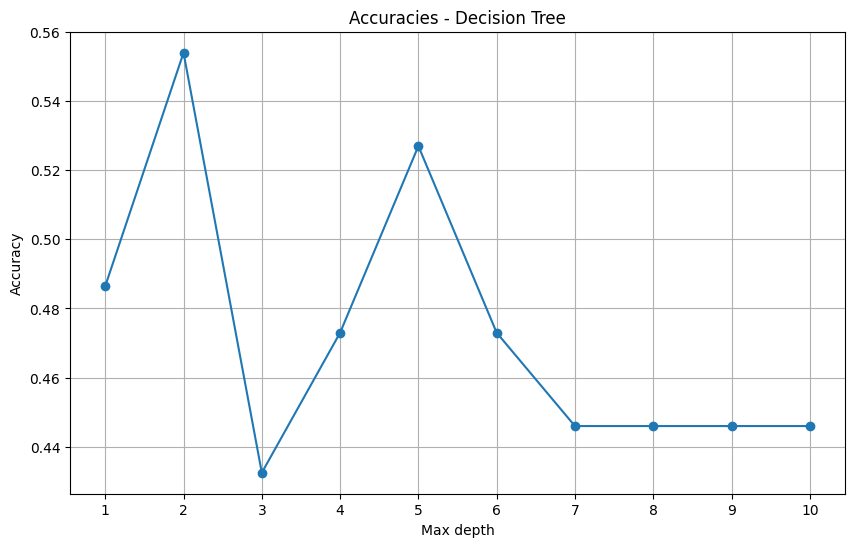

In [ ]:
# Plot de cada Acuracia da Decision Tree
plt.figure(figsize=(10, 6))
plt.plot(results_df_tree['max_depth'], results_df_tree['Accuracy'], marker='o', linestyle='-')
plt.title('Accuracies - Decision Tree')
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
plt.xticks(results_df_tree['max_depth'])
plt.grid()
plt.show()

# **Random Forest**

**1.3** Crie um algoritmo de floresta aleatória, testando os valores 10, 100 e 1000 no hiperparâmetro n_estimators.

In [ ]:
# Random Forest
accuracies_forest = []


for i in [10, 100, 1000]:
  clf_rf = RandomForestClassifier(oob_score=True, n_estimators=i, random_state=42)
  clf_rf.fit(x_train, y_train.values.ravel())
  y_pred = clf_rf.predict(x_test)

  accuracy2 = metrics.accuracy_score(y_test, y_pred)
  oob_score = clf_rf.oob_score_
  print(f"Accuracy (n_estimators {i}):", accuracy2, "/ OOB Score:", oob_score)
  accuracies_forest.append({'n_estimators': i, 'Accuracy': accuracy2, 'OOB_Score': oob_score})

print('-'*100)
results_df_forest = pd.DataFrame(accuracies_forest)
best_acc_forest = results_df_forest.loc[results_df_forest["Accuracy"].idxmax()]

print(f"Accuracy Max (n_estimators {int(best_acc_forest['n_estimators'])}): {best_acc_forest['Accuracy']} / OOB Score: {best_acc_forest['OOB_Score']}")

Accuracy (n_estimators 10): 0.5945945945945946 / OOB Score: 0.4764705882352941
Accuracy (n_estimators 100): 0.527027027027027 / OOB Score: 0.4411764705882353
Accuracy (n_estimators 1000): 0.44594594594594594 / OOB Score: 0.4
----------------------------------------------------------------------------------------------------
Accuracy Max (n_estimators 10): 0.5945945945945946 / OOB Score: 0.4764705882352941


In [ ]:
results_df_forest

,n_estimators,Accuracy,OOB_Score
0,10,0.594595,0.476471
1,100,0.527027,0.441176
2,1000,0.445946,0.400000


**2.3** Teste diferentes critérios para a floresta (gini e log_loss).

In [ ]:
criterion = {'gini':0, 'log_loss':0, 'entropy':0}


for k in criterion.keys():
  clf_rf = RandomForestClassifier(criterion=k, oob_score=True, n_estimators=1000, random_state=42)
  clf_rf.fit(x_train, y_train.values.ravel())
  y_pred = clf_rf.predict(x_test)

  print(f"Accuracy: {k}",metrics.accuracy_score(y_test, y_pred))
  criterion[k] = metrics.accuracy_score(y_test, y_pred)

print("-"*100)
print(f"Accuracy Max ({max(criterion,key=criterion.get)}): {max(criterion.values())}")

Accuracy: gini 0.44594594594594594
Accuracy: log_loss 0.44594594594594594
Accuracy: entropy 0.44594594594594594
----------------------------------------------------------------------------------------------------
Accuracy Max (gini): 0.44594594594594594


**3.3** Teste diferentes critérios para o parâmetro max_depth, tal como foi feito para a árvore de decisão.

In [ ]:
accuracies_forest2 = []


for i in range (1, 11):
  for k in [10, 100, 1000]:
    clf_rf = RandomForestClassifier(criterion='gini', oob_score=True, n_estimators=k, max_depth=i, random_state=42)
    clf_rf.fit(x_train, y_train.values.ravel())
    y_pred = clf_rf.predict(x_test)

    accuracy3 = metrics.accuracy_score(y_test, y_pred)
    oob_score2 = clf_rf.oob_score_
    # print(f'Max Depth: {i}')
    # print(f'n_estimators: {k}')
    # print(f"Accuracy:", accuracy3)
    # print(f"OOB Score:", oob_score2)
    accuracies_forest2.append({'n_estimators': k, 'max_depth': i, 'Accuracy': accuracy3, 'OOB_Score': oob_score2})
    clf_report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True))

best_results_df_forest = pd.DataFrame(accuracies_forest2)
best_acc_forest2 = best_results_df_forest.loc[best_results_df_forest["Accuracy"].idxmax()]

print(f"Accuracy Max (n_estimators {int(best_acc_forest2['n_estimators'])} & max_depth {int(best_acc_forest2['max_depth'])}): {best_acc_forest2['Accuracy']} / OOB Score: {best_acc_forest2['OOB_Score']}")
clf_report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True))
print('-'*100)
print(f"Classification Report:\n\n{clf_report}")
print('-'*100)
print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}\n")

Accuracy Max (n_estimators 10 & max_depth 8): 0.5945945945945946 / OOB Score: 0.4823529411764706
----------------------------------------------------------------------------------------------------
Classification Report:

                   0          1  accuracy  macro avg  weighted avg
precision   0.444444   0.447368  0.445946   0.445906      0.445906
recall      0.432432   0.459459  0.445946   0.445946      0.445946
f1-score    0.438356   0.453333  0.445946   0.445845      0.445845
support    37.000000  37.000000  0.445946  74.000000     74.000000
----------------------------------------------------------------------------------------------------
Confusion Matrix: 
[[16 21]
 [20 17]]



In [ ]:
best_results_df_forest

,n_estimators,max_depth,Accuracy,OOB_Score
0,10,1,0.554054,0.441176
1,100,1,0.513514,0.417647
2,1000,1,0.513514,0.370588
3,10,2,0.472973,0.482353
4,100,2,0.513514,0.447059
5,1000,2,0.513514,0.329412
6,10,3,0.472973,0.494118
7,100,3,0.540541,0.458824
8,1000,3,0.527027,0.341176
9,10,4,0.500000,0.523529


Acuracia em relacao a cada **Random Forest**

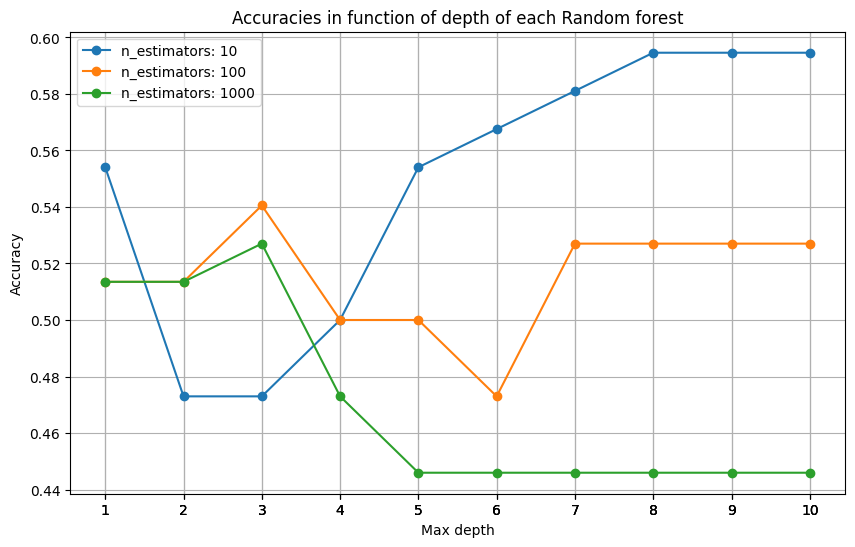

In [ ]:
# Plot da Acuracia de cada Random Forest
plt.figure(figsize=(10, 6))

for n in [10, 100, 1000]:
    subset = best_results_df_forest[best_results_df_forest['n_estimators'] == n]
    plt.plot(subset['max_depth'], subset['Accuracy'], marker='o', label=f'n_estimators: {n}')

plt.title('Accuracies in function of depth of each Random forest')
plt.xlabel('Max depth')
plt.ylabel('Accuracy')
plt.xticks(best_results_df_forest['max_depth'])
plt.grid()
plt.legend()
plt.show()

# **Validando os modelos**

Cross-Validation

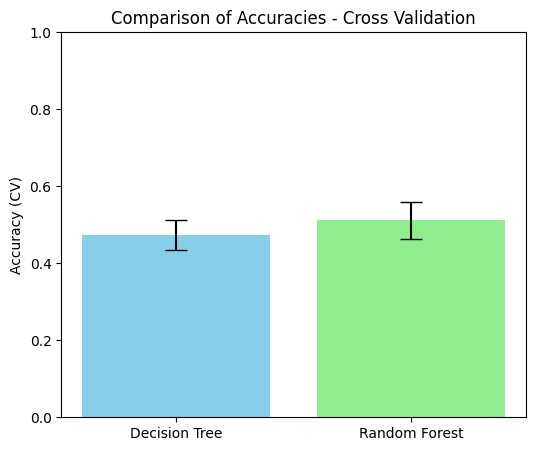

In [ ]:
def plot_cv_results(results_df_tree, best_results_df_forest):
    labels = ["Decision Tree", "Random Forest"]
    medias = [results_df_tree["Accuracy"].mean(), best_results_df_forest["Accuracy"].mean()]
    desvios = [results_df_tree["Accuracy"].std(), best_results_df_forest["Accuracy"].std()]

    plt.figure(figsize=(6, 5))
    plt.bar(labels, medias, yerr=desvios, capsize=8, color=["skyblue", "lightgreen"])
    plt.ylabel("Accuracy (CV)")
    plt.title("Comparison of Accuracies - Cross Validation")
    plt.ylim(0, 1)
    plt.show()

plot_cv_results(results_df_tree, best_results_df_forest)

Curva ROC + AUC

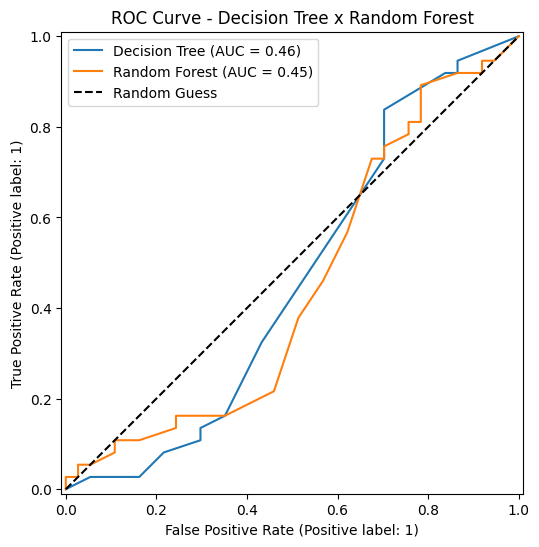

In [ ]:
def plot_roc_curve(model1, model2, x_test, y_test, name1="Model 1", name2="Model 2"):
    plt.figure(figsize=(7, 6))
    RocCurveDisplay.from_estimator(model1, x_test, y_test, ax=plt.gca(), name=name1)
    RocCurveDisplay.from_estimator(model2, x_test, y_test, ax=plt.gca(), name=name2)
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.title(f"ROC Curve - {name1} x {name2}")
    plt.legend()
    plt.show()

plot_roc_curve(clf_dt, clf_rf, x_test, y_test, name1="Decision Tree", name2="Random Forest")

Matriz de Confusao (Nao-Normalizada x Normalizada)

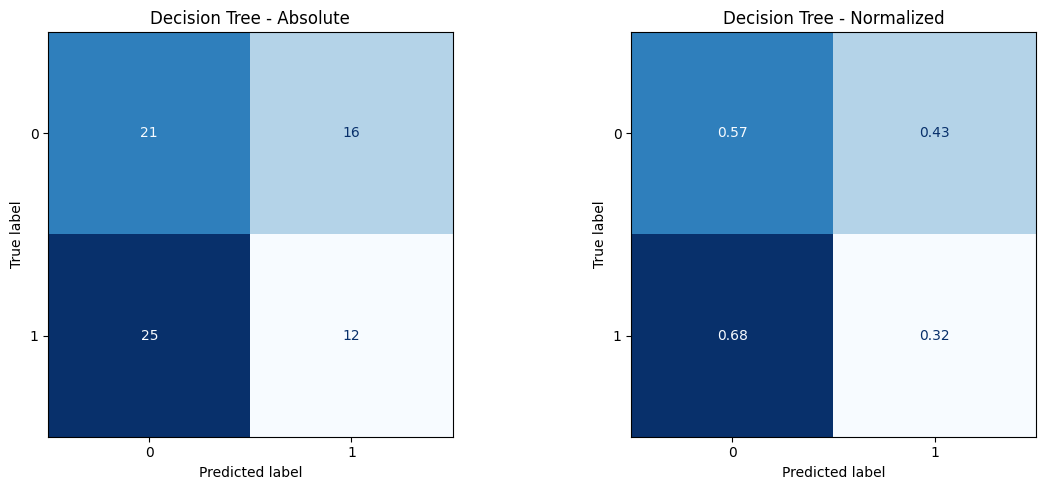

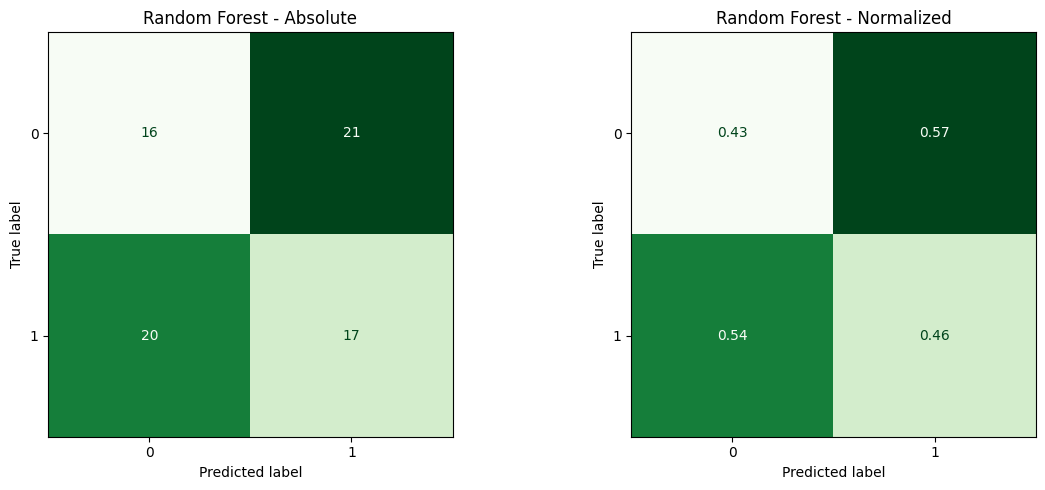

In [ ]:
def plot_confusion_matrices(model, x_test, y_test, name="Model", color="Color"):
    y_pred = model.predict(x_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Absoluta
    cm_abs = confusion_matrix(y_test, y_pred)
    disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_abs)
    disp_abs.plot(ax=axes[0], cmap=color, colorbar=False)
    axes[0].set_title(f"{name} - Absolute")

    # Normalizada
    cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
    disp_norm.plot(ax=axes[1], cmap=color, colorbar=False)
    axes[1].set_title(f"{name} - Normalized")

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(clf_dt, x_test, y_test, name="Decision Tree", color="Blues")
plot_confusion_matrices(clf_rf, x_test, y_test, name="Random Forest", color="Greens")

Learning Curve

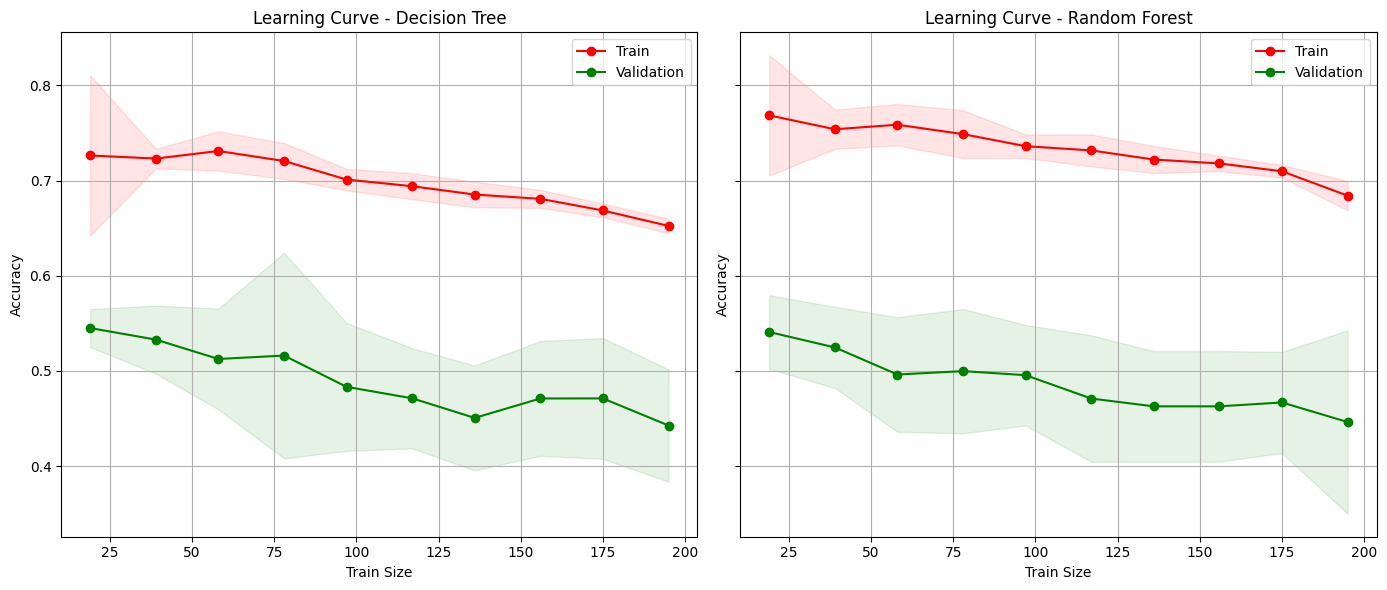

In [ ]:
def plot_learning_curves_side_by_side(models, names, X, y, cv=5, scoring="accuracy", n_jobs=-1):
    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 6), sharey=True)

    # Caso exista apenas um modelo
    if len(models) == 1:
        axes = [axes]

    for ax, model, name in zip(axes, models, names):
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs,
            train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

        # Medias e Desvios padrao
        train_scores_mean = np.mean(train_scores, axis=1)
        train_scores_std = np.std(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)
        test_scores_std = np.std(test_scores, axis=1)

        # Plot
        ax.set_title(f"Learning Curve - {name}")
        ax.set_xlabel("Train Size")
        ax.set_ylabel(scoring.capitalize())
        ax.grid(True)

        ax.fill_between(train_sizes,
                        train_scores_mean - train_scores_std,
                        train_scores_mean + train_scores_std,
                        alpha=0.1, color="r")
        ax.fill_between(train_sizes,
                        test_scores_mean - test_scores_std,
                        test_scores_mean + test_scores_std,
                        alpha=0.1, color="g")

        ax.plot(train_sizes, train_scores_mean, "o-", color="r", label="Train")
        ax.plot(train_sizes, test_scores_mean, "o-", color="g", label="Validation")
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

plot_learning_curves_side_by_side(
    models=[clf_dt, clf_rf],
    names=["Decision Tree", "Random Forest"],
    X=x, y=y)

Importancia das Features

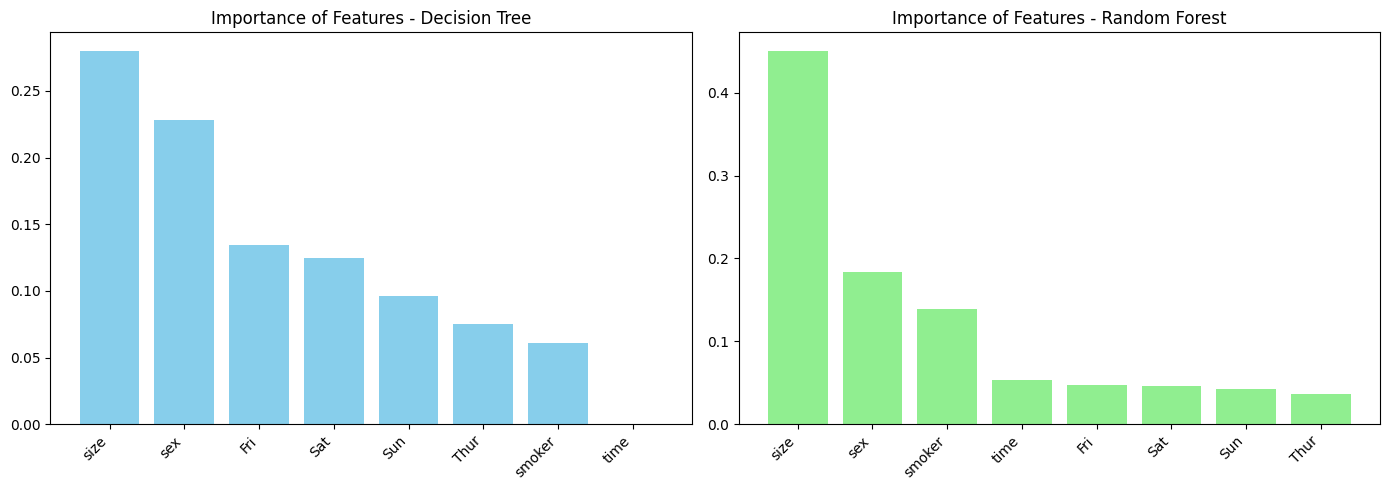

In [ ]:
def plot_feature_importance_side_by_side(model1, model2, name1, name2, feature_names):
    importances1 = model1.feature_importances_
    importances2 = model2.feature_importances_

    indices1 = importances1.argsort()[::-1]
    indices2 = importances2.argsort()[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Decision Tree
    axes[0].bar(range(len(importances1)), importances1[indices1], align="center", color="skyblue")
    axes[0].set_xticks(range(len(importances1)))
    axes[0].set_xticklabels(feature_names[indices1], rotation=45, ha="right")
    axes[0].set_title(f"Importance of Features - {name1}")

    # Random Forest
    axes[1].bar(range(len(importances2)), importances2[indices2], align="center", color="lightgreen")
    axes[1].set_xticks(range(len(importances2)))
    axes[1].set_xticklabels(feature_names[indices2], rotation=45, ha="right")
    axes[1].set_title(f"Importance of Features - {name2}")

    plt.tight_layout()
    plt.show()

plot_feature_importance_side_by_side(clf_dt, clf_rf, "Decision Tree", "Random Forest", x.columns.values)

# Conclusoes

Sobre a base:
O dataset tips.csv trata-se de uma base de dados pequena, com apenas 244 registros no total, o que a torna uma base com alta Variabilidade. Tambem, por se tratar de uma base com variaveis categoricas com poucas categorias e com modelos de machine learning aplicados como Random Forest e Decision Tree, acaba existindo a possibilidade de se ter uma certa limitacao na capacidade dos modelos de encontrar separacoes mais consistentes nas classificacoes e uma maior propensao a overfitting.

---

Sobre a validacao: No processo de validacao, e possivel identificar que, mesmo com a base de dados bem tratada, ainda se tem resultados instaveis e com a presenca de Overfitting, o que leva a conclusoes de que, por mais que os modelos aplicados possuam tal tendencia a Overfitting, a base de dados, por ser pequena, possui uma alta variancia e, tambem, nao foi aplicado Gridsearch para uma melhor hiperparametrizacao dos modelos. Tais fatores explicam os resultados nao agradaveis obtidos pelos modelos, o que leva a concluir que nossa base de dados tips.csv necessita de mais dados, variaveis categoricas melhores e os modelos precisam de uma melhor hiperparametrizacao, para que assim, seja possivel obter resultado mais positivos quando aplicado modelos de Random Forest e Decision Tree a esta base.
